In [12]:
import numpy as np

import grover
import utils
import entropy
import quantum_random_walk

# Grover algorithm entropy analysis

In [13]:
shots=10240
qubits=8 # use 10 with caution
marked_state = 0b111  # target state as integer (|111> = 7)

In [14]:
# We test with applying Grover operator G k times and measure success probability
for k in range(1, 11):
    qc = grover.construct_grover(qubits, k, marked_state)
    counts = utils.measure(qc, shots,skip_qubits=[qubits])

    marked_bitstring = format(marked_state, f'0{qubits}b')
    success_counts = counts.get(marked_bitstring, 0)
    probability = success_counts / shots
    theta = np.arcsin(np.sqrt(1/2**qubits))
    prediction = np.sin((2*k+1)*theta)**2
    print(f"k={k:2d}  success state probability: {probability:.5f}   theoretical prediction: {prediction:.5f}")

k= 1  success state probability: 0.03398   theoretical prediction: 0.03479
k= 2  success state probability: 0.09873   theoretical prediction: 0.09464
k= 3  success state probability: 0.17441   theoretical prediction: 0.17972
k= 4  success state probability: 0.28096   theoretical prediction: 0.28474
k= 5  success state probability: 0.40557   theoretical prediction: 0.40317
k= 6  success state probability: 0.53896   theoretical prediction: 0.52762
k= 7  success state probability: 0.64570   theoretical prediction: 0.65035
k= 8  success state probability: 0.76240   theoretical prediction: 0.76372
k= 9  success state probability: 0.86240   theoretical prediction: 0.86068
k=10  success state probability: 0.93799   theoretical prediction: 0.93518


In [15]:
k_optimal = grover.optimal_iterations(qubits) 
print(f"optimal amount of repetitions: {k_optimal}")

qc = grover.construct_grover(qubits, k_optimal, marked_state=marked_state)
counts = utils.measure(qc, shots, skip_qubits=[qubits])

marked_bitstring = format(marked_state, f'0{qubits}b')
success_counts = counts.get(marked_bitstring, 0)
probability = success_counts / shots
theta = np.arcsin(np.sqrt(1/2**qubits))
prediction = np.sin((2*k_optimal+1)*theta)**2
print(f"k={k_optimal:2d}  success state probability: {probability:.5f}   theoretical prediction: {prediction:.5f}")


optimal amount of repetitions: 12
k=12  success state probability: 1.00000   theoretical prediction: 0.99995


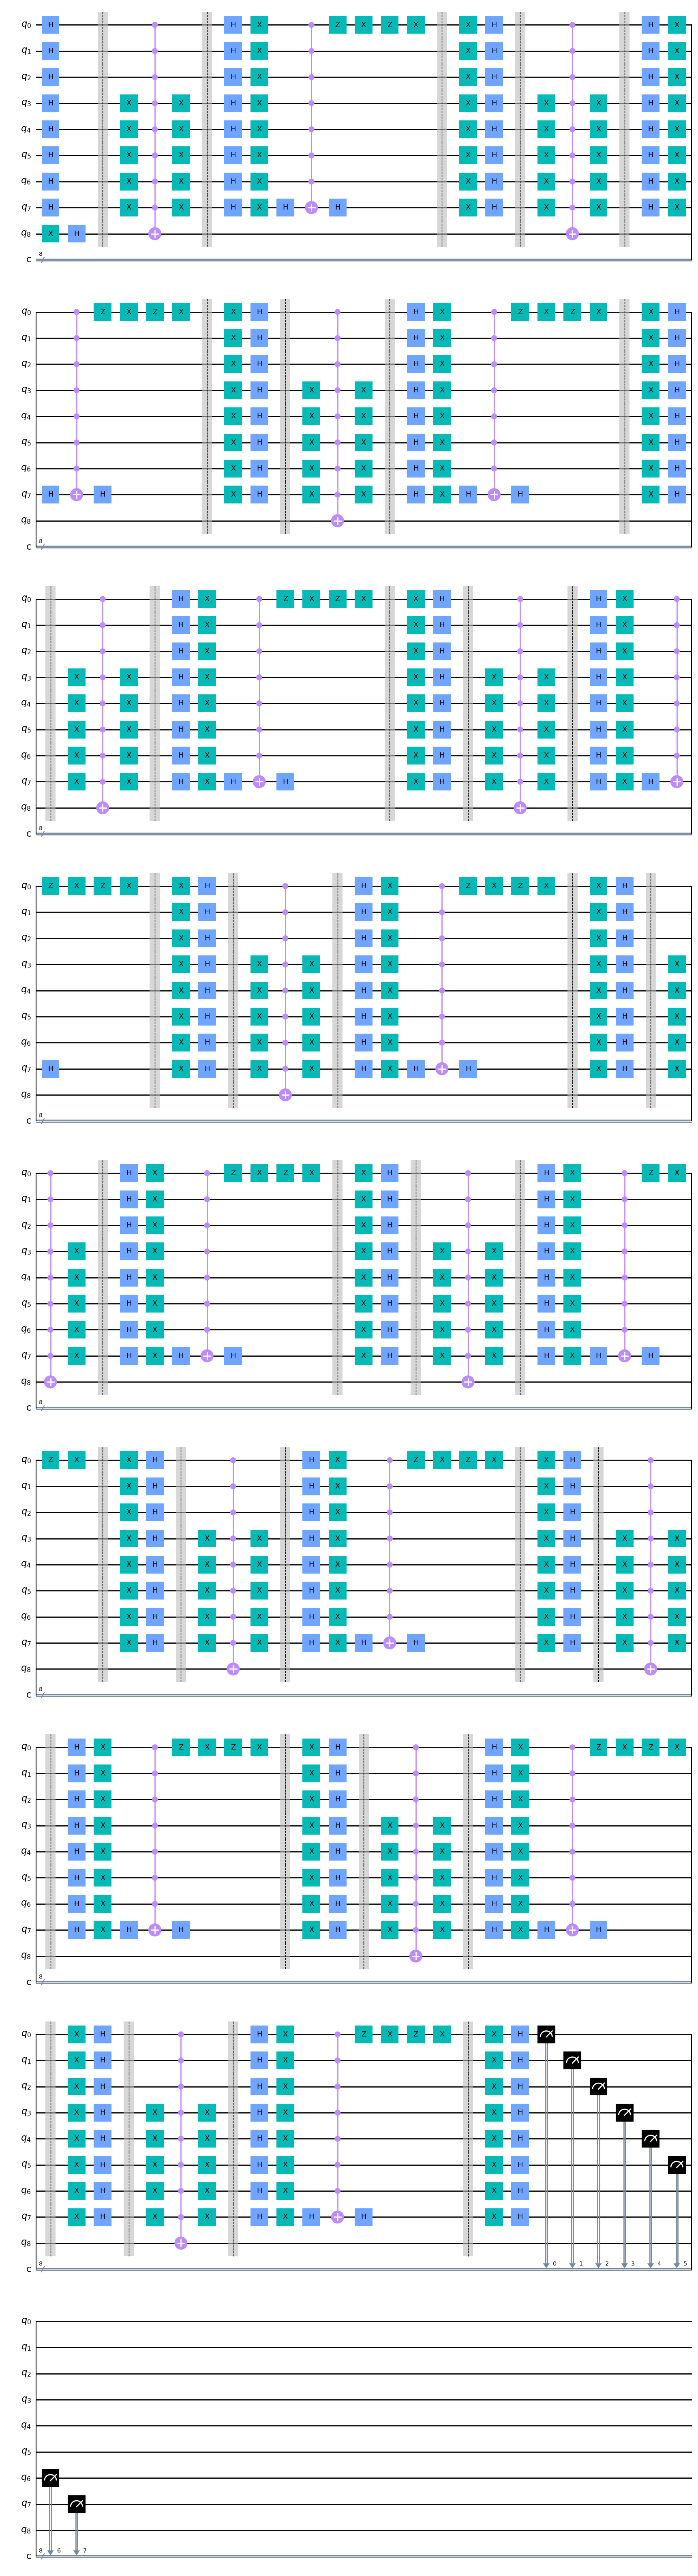

In [16]:
qc.draw(output="mpl",style="clifford")

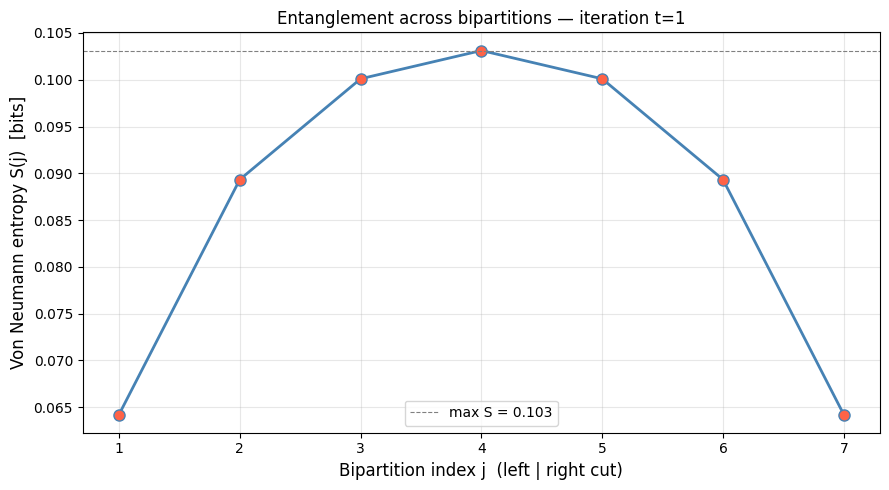

In [17]:
t_fixed = 1
qc = grover.construct_grover(qubits, k=t_fixed, marked_state=marked_state)
entropy.plot_entropy_vs_j(qc, n=qubits, t= t_fixed)

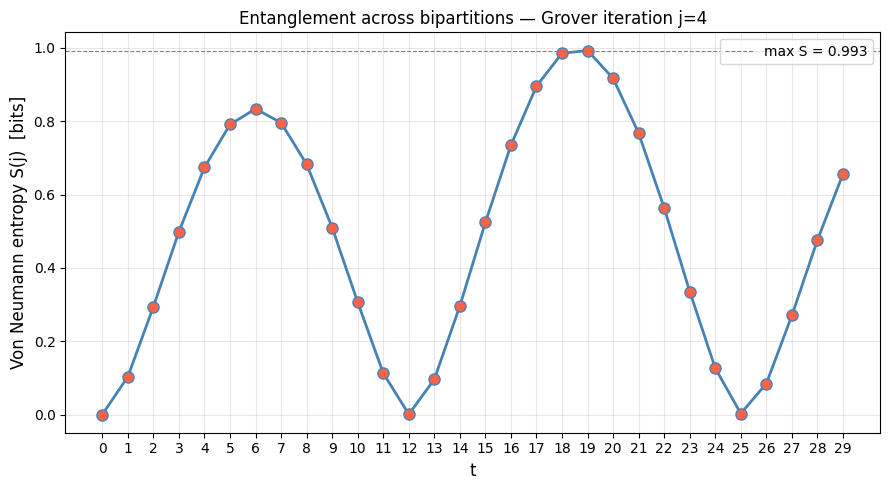

In [18]:
grover_lambda = lambda t: grover.construct_grover(qubits, t, marked_state=marked_state)
entropy.plot_entropy_vs_t(grover_lambda, n=qubits, j=qubits // 2, t_max=30)

# Quantum random walk entropy analysis

In [19]:
shots=1024
qubits = 7
t=50
shots = 1024

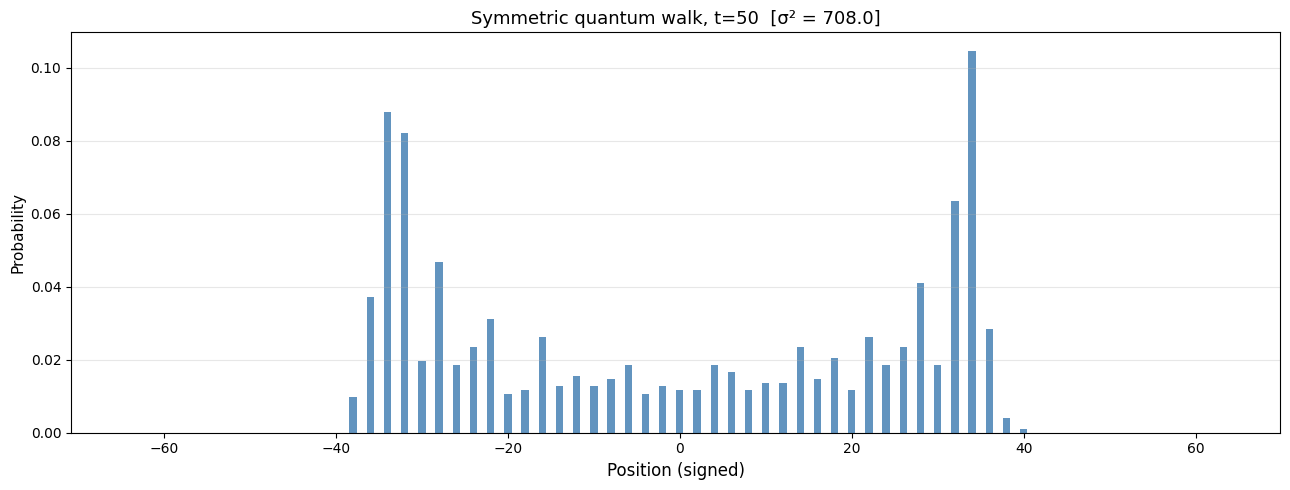

In [20]:
quantum_random_walk.plot_walk(n_position_qubits=qubits, steps=t, shots = shots)

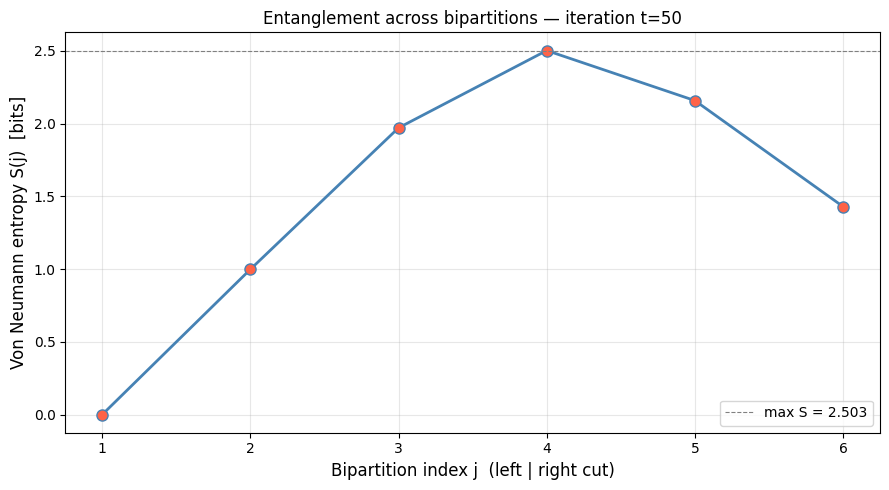

In [21]:
t_fixed = 50
qc = quantum_random_walk.construct_walk(qubits, t_fixed)
entropy.plot_entropy_vs_j(qc, n=qubits, t= t_fixed)

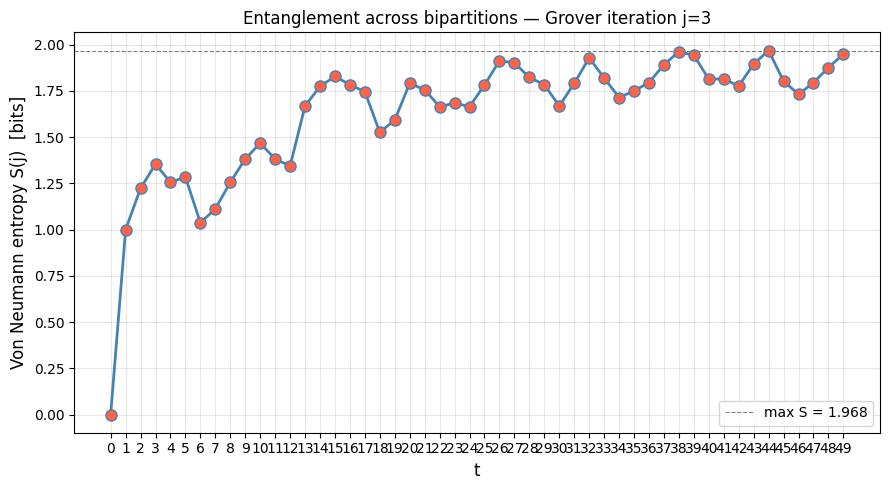

In [23]:
quantum_walk_lambda = lambda t: quantum_random_walk.construct_walk(qubits, t)
entropy.plot_entropy_vs_t(quantum_walk_lambda, n=qubits, j=qubits // 2, t_max=50)